history-server-files//pagerank/vms3cores/3/application_1717138188434_0001
slave207 0.0 257.349
slave202 0.0 261.689
slave201 0.0 256.521
slave208 0.0 260.847
slave203 0.0 256.564
slave209 0.0 256.417


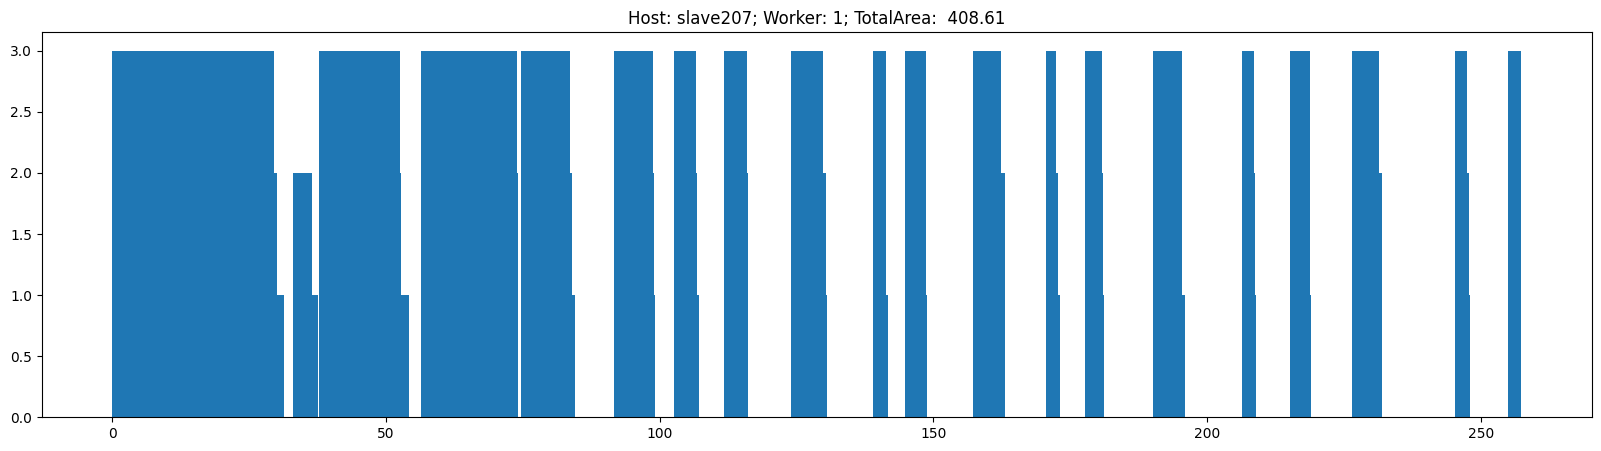

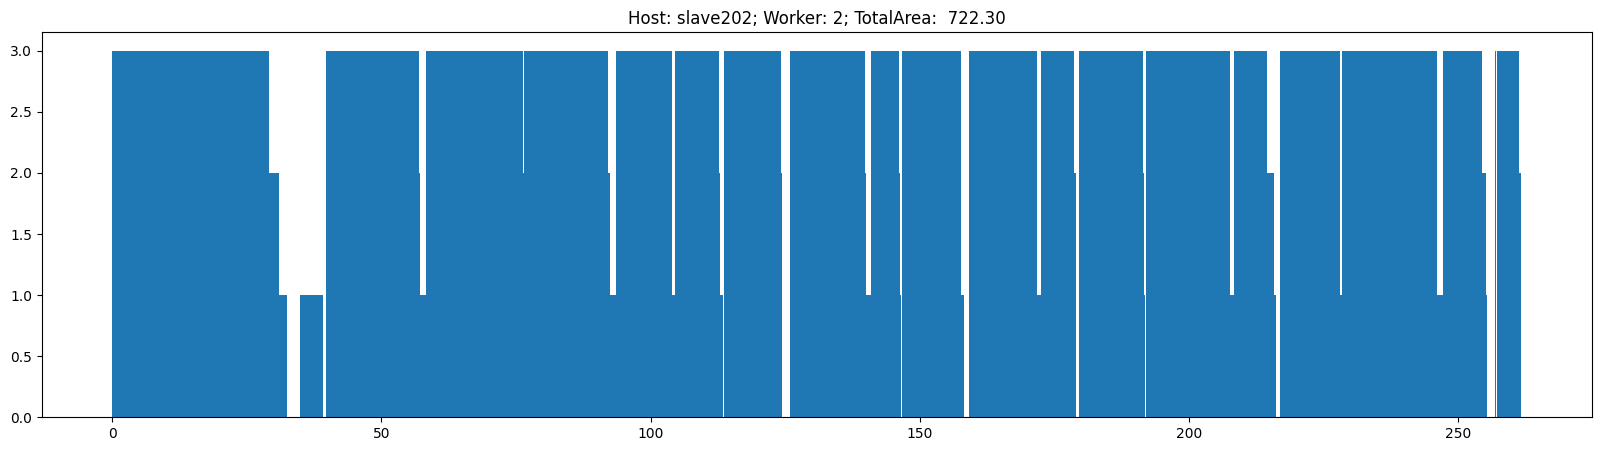

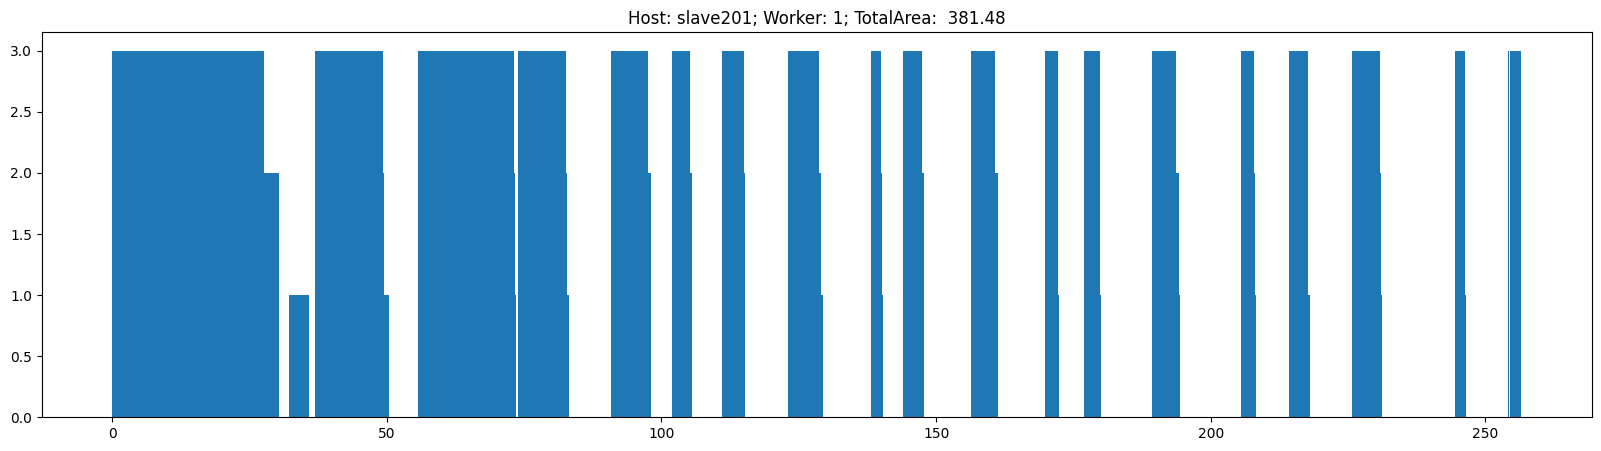

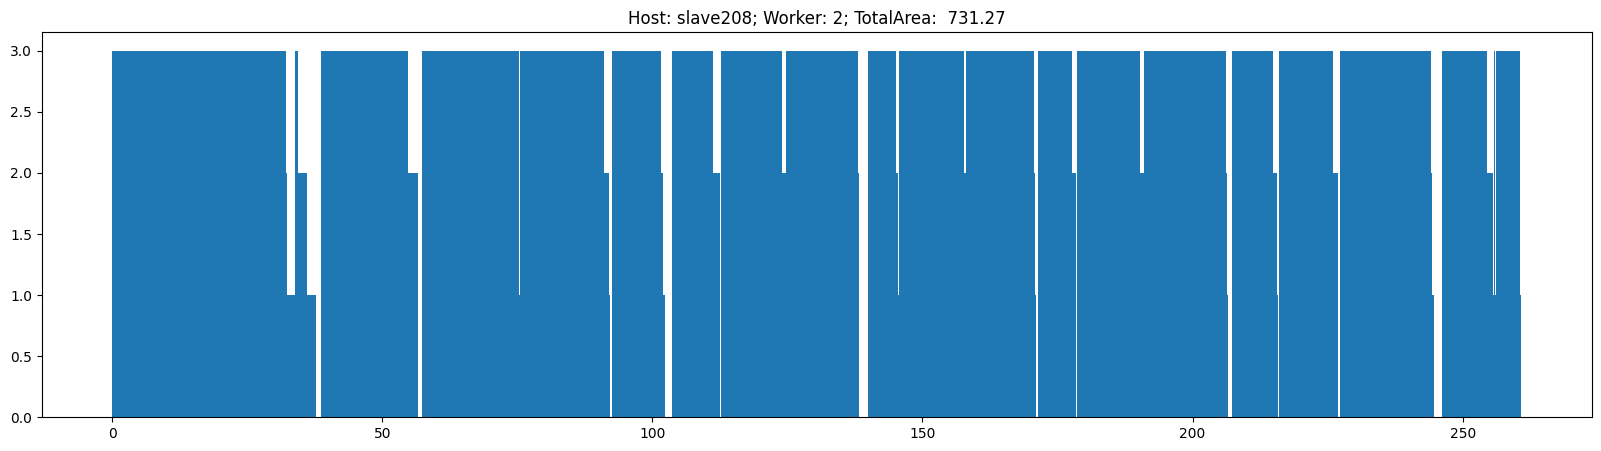

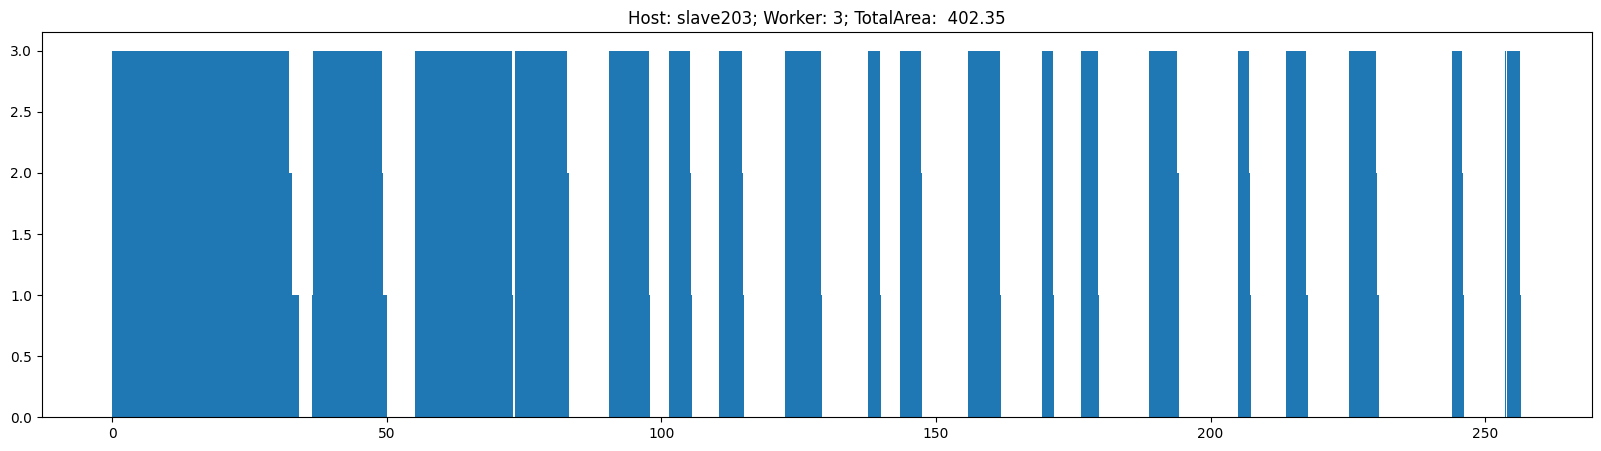

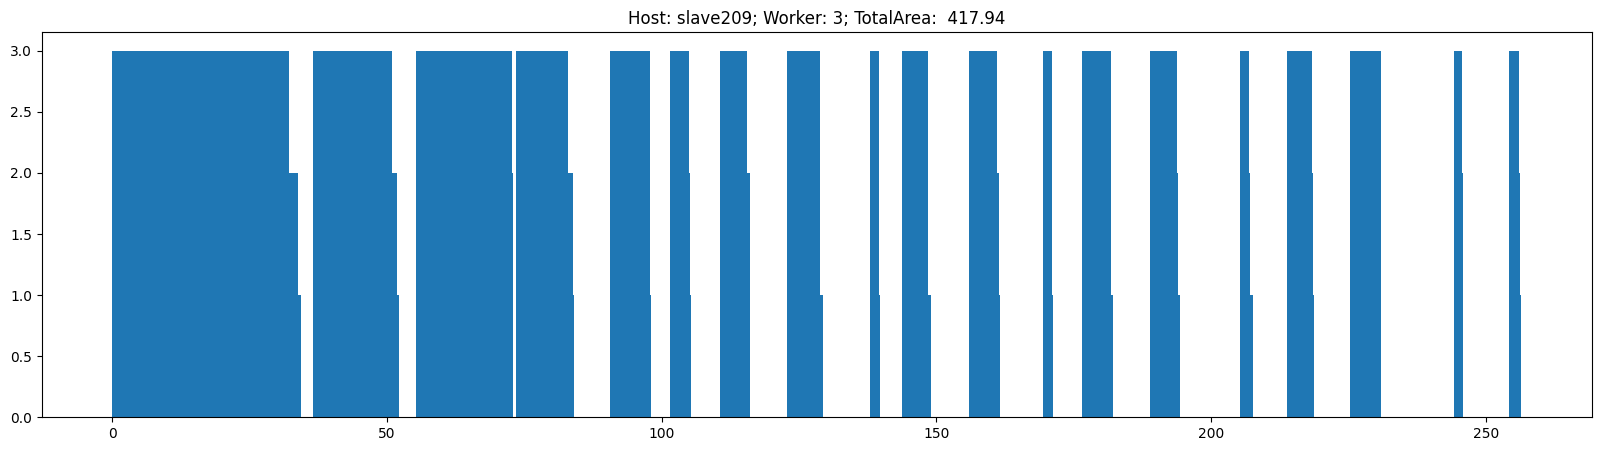

In [1]:
import json
import sys

import pduplots as pp
import pduhistoryserver as hs
from pdumetrics import PowerMetrics
import pduoutletmap as om

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


def datafiles_iterator(output_dir):
    with open("history-server-tree.json", "r") as f:
        directory_tree = json.load(f)

    directory_tree = directory_tree[0]
    base_dir = directory_tree["name"]
    for app_tree in directory_tree["contents"]:
        app_dir = app_tree["name"]
        if app_dir != "pagerank": continue
        for vmconfig_tree in app_tree["contents"][:1]:
            vmconfig_dir = vmconfig_tree["name"]
            for num_machines_tree in vmconfig_tree["contents"][:1]:
                num_machines_dir = num_machines_tree["name"]
                for datafile_tree in num_machines_tree["contents"][:1]:
                    datafile = datafile_tree["name"]
                    datafile_full_path = f"{base_dir}/{app_dir}/{vmconfig_dir}/{num_machines_dir}/{datafile}"
                    plot_title = f"{output_dir}/{app_dir}-{vmconfig_dir}-{num_machines_dir}-{datafile}"
                    yield datafile_full_path, plot_title


output_dir = sys.argv[1]

#pm = PowerMetrics("all_power_processed.csv.gz")
for datafile, plot_title in datafiles_iterator(output_dir):
    print(datafile)
    timeline_per_host = hs.active_tasks_timeline_per_host(datafile)
    for host in timeline_per_host:
        timestamps, task_count = timeline_per_host[host]
        df = pd.DataFrame()
        def normalize(d1,mind):
            return (d1-mind).total_seconds()
        df["timestamp"] = timestamps
        mind = df["timestamp"].min()
        def normalize(d1):
            return (d1-mind).total_seconds()
        df["timestamp"] = df["timestamp"].apply(normalize)
        df["task_count"] = task_count
        print(host, df["timestamp"].min(), df["timestamp"].max())

        task_counts = list(df["task_count"])
        timestamps = list(df["timestamp"])
        widths = []
        bar_pos = []
        y = []
        app_area = 0
        for i in range(1,len(timestamps)):
            width = (timestamps[i] - timestamps[i-1])
            widths.append(width)
            bar_pos.append((timestamps[i] + timestamps[i-1]) / 2)
            y.append(task_counts[i])
            app_area += width * task_counts[i]
        
        plt.figure(figsize=(20,5))
        plt.title(f"Host: {host}; Worker: {om.get_worker_from_host(host)}; TotalArea: {app_area: .2f}")
        plt.bar(bar_pos, y, width=widths)

history-server-files//terasort/vms3cores/3/application_1716833917453_0001
1 34.53 510.407
2 39.628 521.906
3 37.439 506.045
history-server-files//terasort/vms6cores/3/application_1716648048801_0001
1 46.806 991.525
2 40.961 981.432
3 60.513 996.35


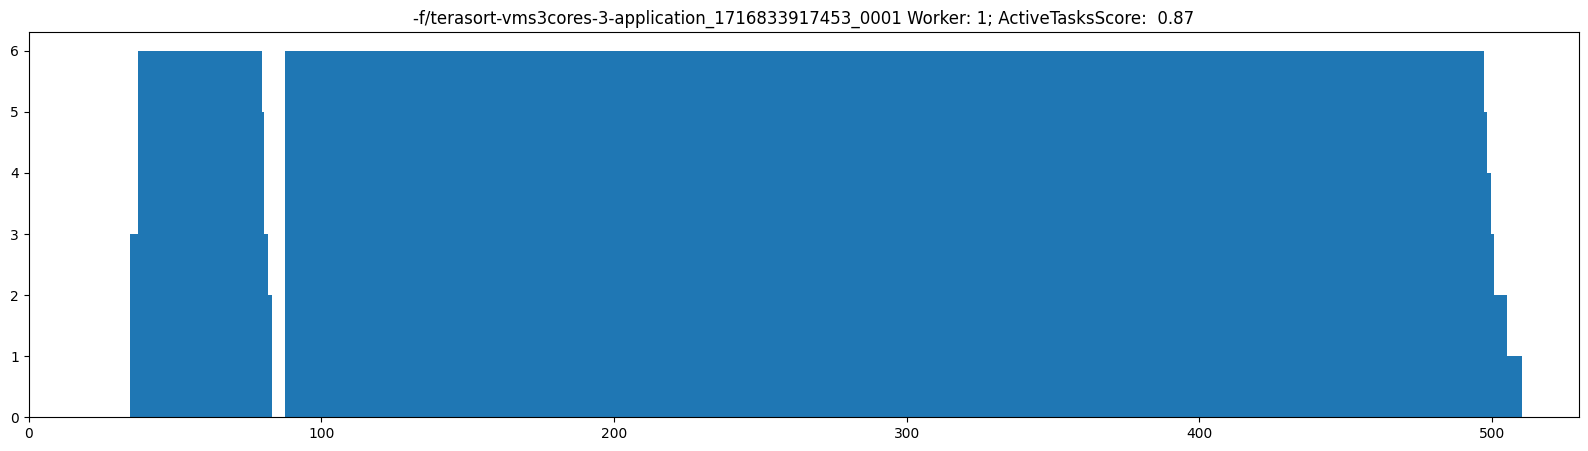

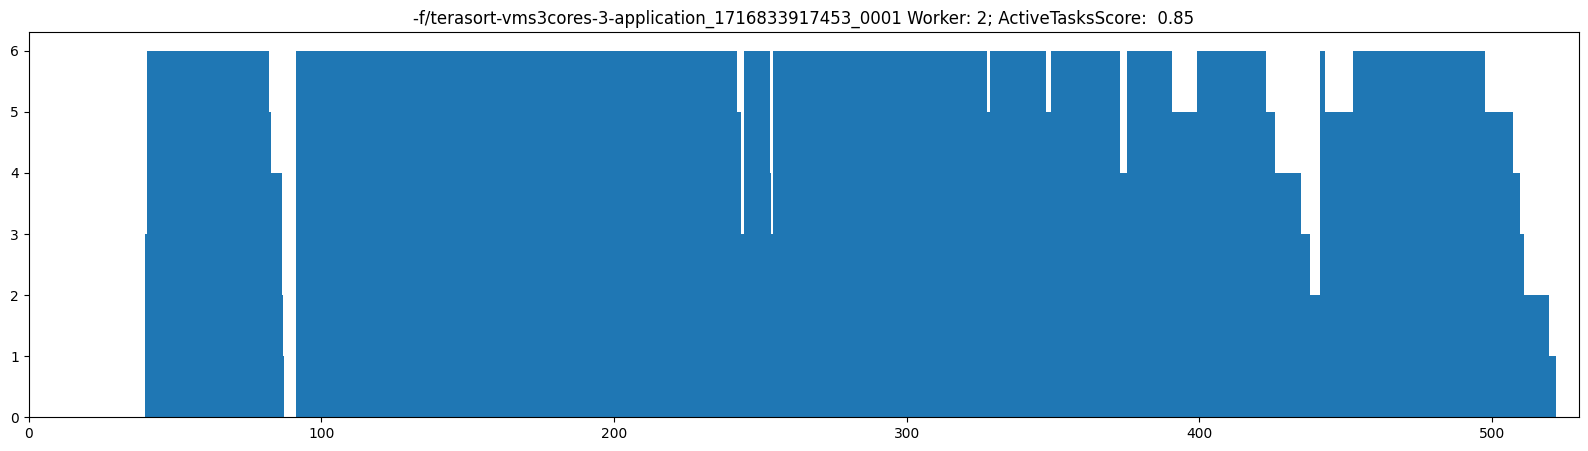

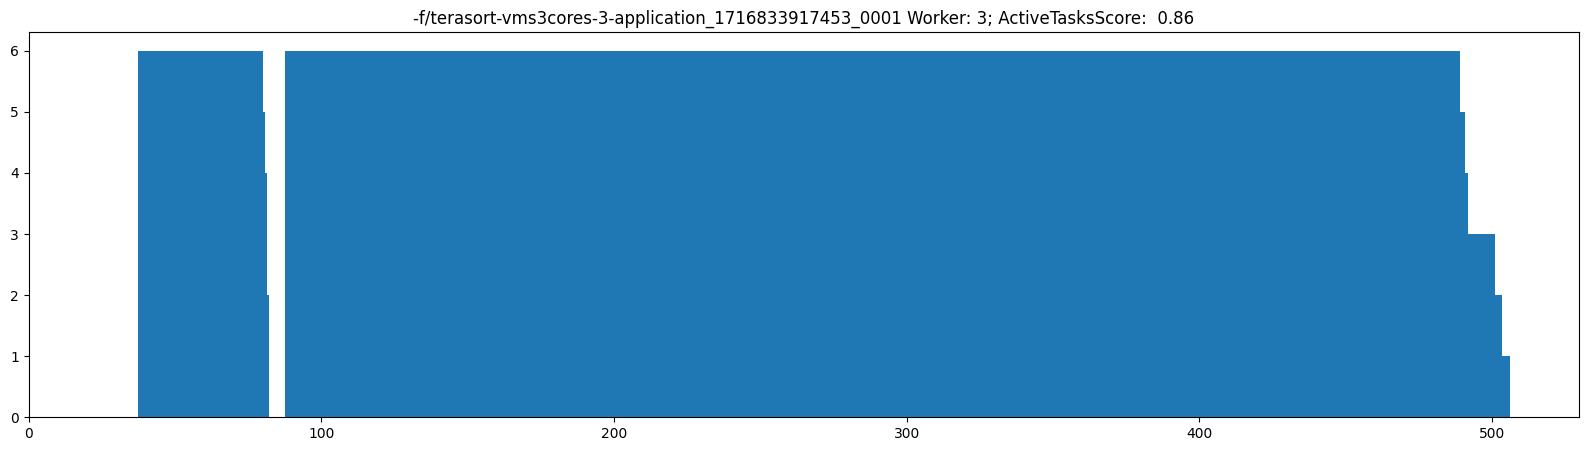

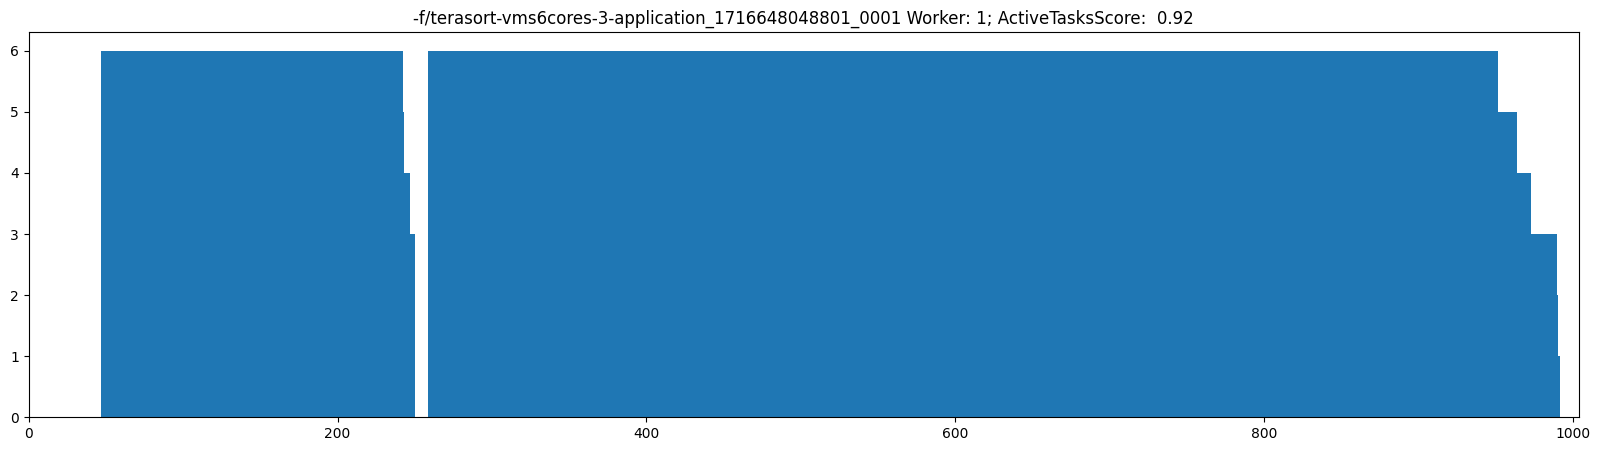

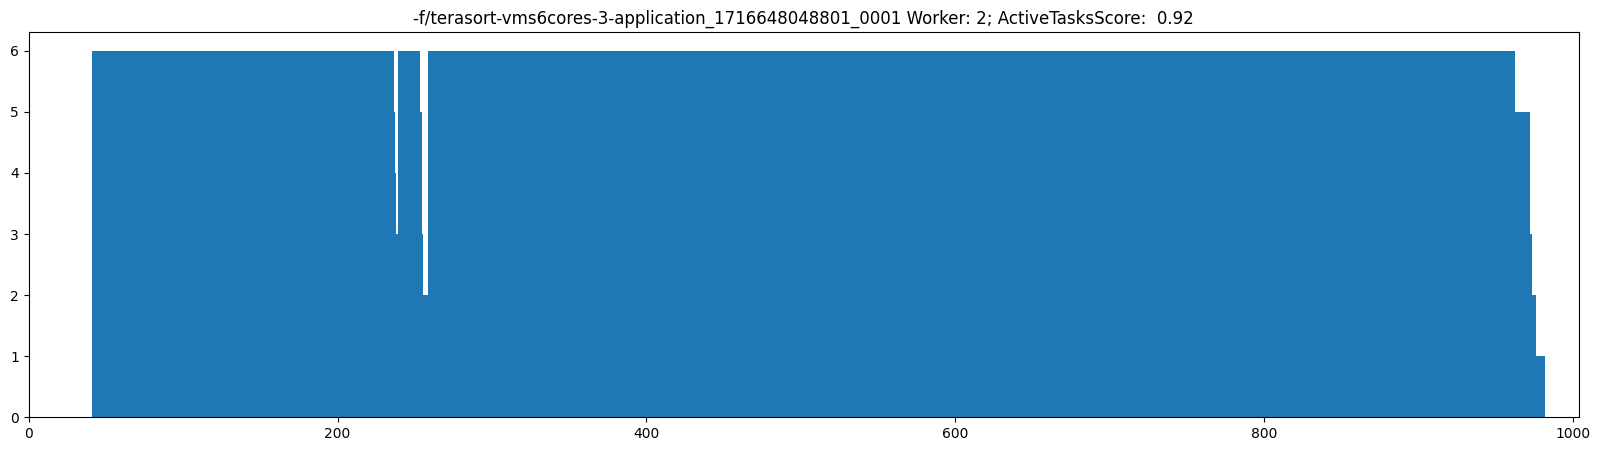

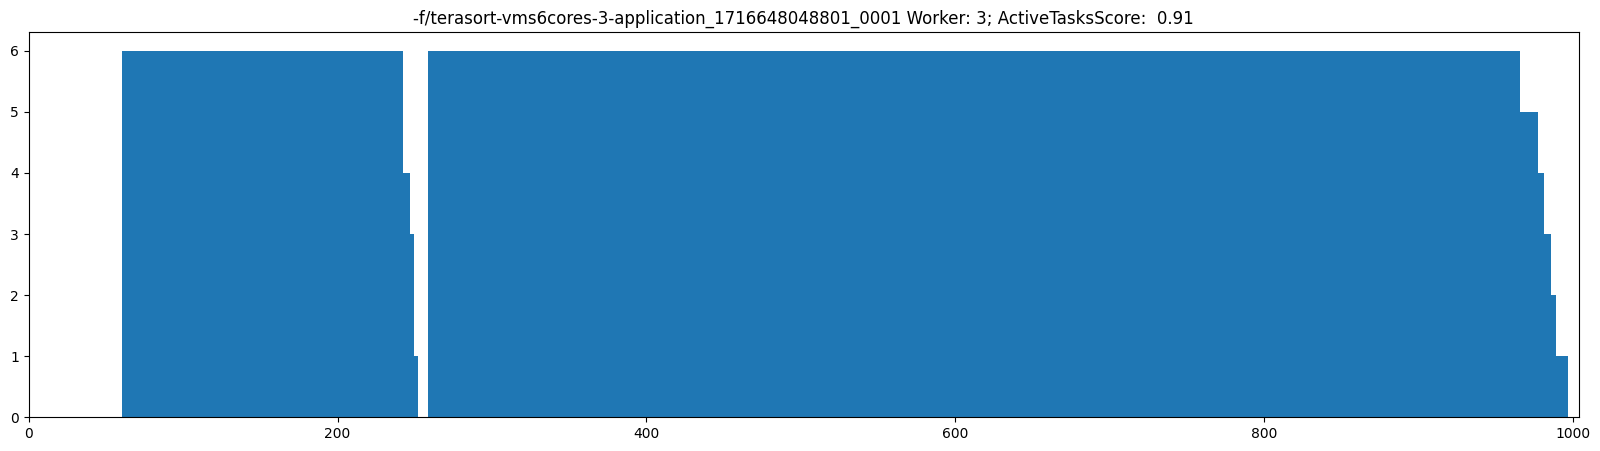

In [4]:
import json
import sys

import pduplots as pp
import pduhistoryserver as hs
from pdumetrics import PowerMetrics
import pduoutletmap as om

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


def datafiles_iterator(output_dir):
    with open("history-server-tree.json", "r") as f:
        directory_tree = json.load(f)

    directory_tree = directory_tree[0]
    base_dir = directory_tree["name"]
    for app_tree in directory_tree["contents"]:
        app_dir = app_tree["name"]
        if app_dir != "terasort": continue
        for vmconfig_tree in app_tree["contents"][:2]:
            vmconfig_dir = vmconfig_tree["name"]
            for num_machines_tree in vmconfig_tree["contents"][:1]:
                num_machines_dir = num_machines_tree["name"]
                for datafile_tree in num_machines_tree["contents"][:1]:
                    datafile = datafile_tree["name"]
                    datafile_full_path = f"{base_dir}/{app_dir}/{vmconfig_dir}/{num_machines_dir}/{datafile}"
                    plot_title = f"{output_dir}/{app_dir}-{vmconfig_dir}-{num_machines_dir}-{datafile}"
                    yield datafile_full_path, plot_title


output_dir = sys.argv[1]

#pm = PowerMetrics("all_power_processed.csv.gz")
for datafile, plot_title in datafiles_iterator(output_dir):
    print(datafile)
    timeline_per_worker = hs.active_tasks_timeline_per_worker(datafile)
    start, end = hs.get_time_interval(datafile)
    for worker in sorted(timeline_per_worker):
        timestamps, task_count = timeline_per_worker[worker]
        df = pd.DataFrame()
        df["timestamp"] = timestamps
        mind = df["timestamp"].min()
        def normalize(d1):
            return (d1-start).total_seconds()
        df["timestamp"] = df["timestamp"].apply(normalize)
        df["task_count"] = task_count
        print(worker, df["timestamp"].min(), df["timestamp"].max())

        task_counts = list(df["task_count"])
        timestamps = list(df["timestamp"])
        widths = []
        bar_pos = []
        y = []
        app_area = 0
        for i in range(1,len(timestamps)):
            width = (timestamps[i] - timestamps[i-1])
            widths.append(width)
            bar_pos.append((timestamps[i] + timestamps[i-1]) / 2)
            y.append(task_counts[i])
            app_area += width * task_counts[i]

        total_area = (end - start).total_seconds() * max(task_counts)
        plt.figure(figsize=(20,5))
        plt.xlim(0, (end-start).total_seconds())
        plt.title(f"{plot_title} Worker: {worker}; ActiveTasksScore: {app_area / total_area: .2f}")
        plt.bar(bar_pos, y, width=widths)

1 34.16 452.513
2 42.027 451.863
3 42.027 452.642
1 35.29 573.821
2 44.669 573.063
3 44.67 573.722


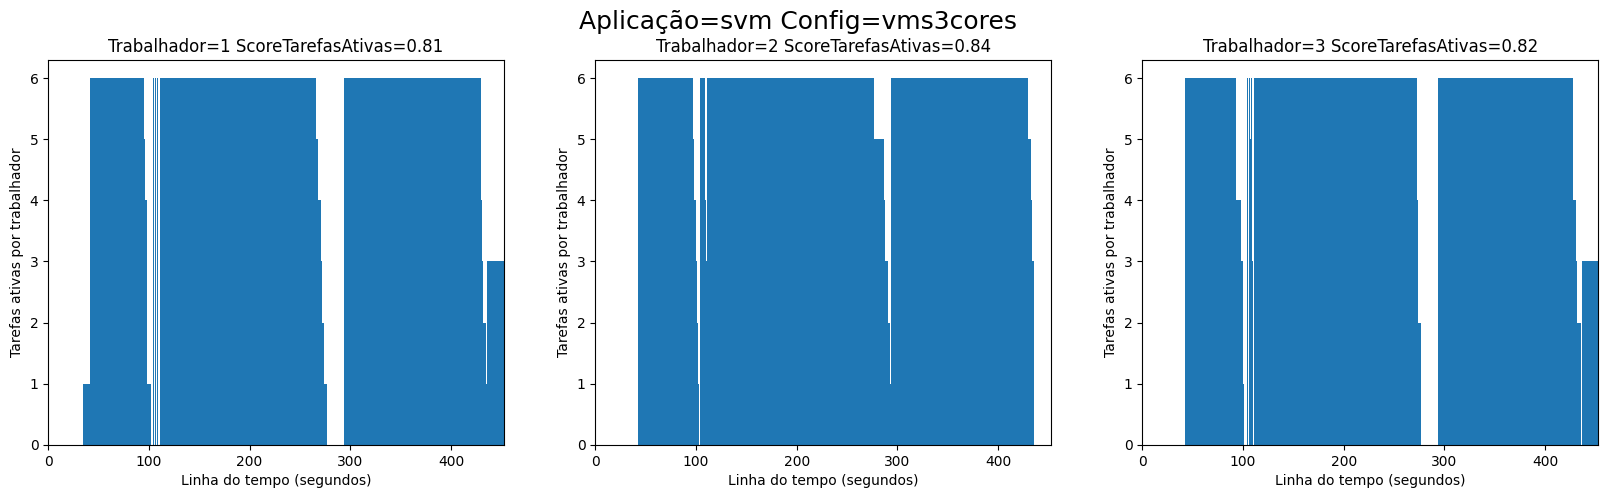

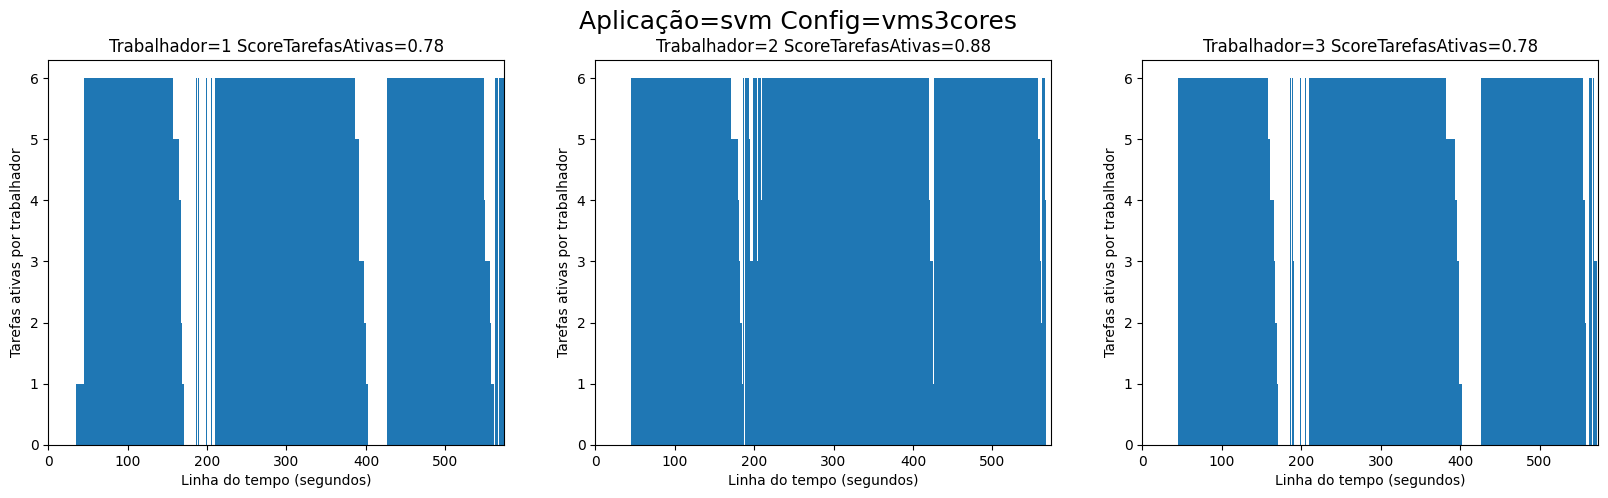

In [30]:
import json
import sys

import pduplots as pp
import pduhistoryserver as hs
from pdumetrics import PowerMetrics
import pduoutletmap as om
import pduutil as pu

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

maxplots = 2
cur_plot = 0
for datafile, config in pu.datafiles_iterator():
    app = config["app"]
    if app != "svm": continue
    if cur_plot == maxplots: break
    cur_plot += 1
    timeline_per_worker = hs.active_tasks_timeline_per_worker(datafile)
    start, end = hs.get_time_interval(datafile)
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
    vm_config = config["vm_config"]
    fig.suptitle(f"Aplicação={app} Config={vm_config}\n", fontsize=18)
    axs = iter(axs)
    for worker in sorted(timeline_per_worker):
        timestamps, task_count = timeline_per_worker[worker]
        df = pd.DataFrame()
        df["timestamp"] = timestamps
        mind = df["timestamp"].min()
        def normalize(d1):
            return (d1-start).total_seconds()
        df["timestamp"] = df["timestamp"].apply(normalize)
        df["task_count"] = task_count
        print(worker, df["timestamp"].min(), df["timestamp"].max())

        task_counts = list(df["task_count"])
        timestamps = list(df["timestamp"])
        widths = []
        bar_pos = []
        y = []
        app_area = 0
        for i in range(1,len(timestamps)):
            width = (timestamps[i] - timestamps[i-1])
            widths.append(width)
            bar_pos.append((timestamps[i] + timestamps[i-1]) / 2)
            y.append(task_counts[i])
            app_area += width * task_counts[i]

        total_area = (end - start).total_seconds() * max(task_counts)
        ax = next(axs)
        ax.set_xlim(0, (end-start).total_seconds())
        ax.set_title(f"Trabalhador={worker} ScoreTarefasAtivas={app_area / total_area:.2f}")
        ax.set_xlabel("Linha do tempo (segundos)")
        ax.set_ylabel("Tarefas ativas por trabalhador")
        ax.bar(bar_pos, y, width=widths)